# 🏥 VLM Knowledge Distillation on VQA-RAD
## Teacher: CLIP-ViT-L/14 → Student: MobileNetV2

**Pipeline Overview:**
1. Load & preprocess VQA-RAD dataset
2. Train/Test/Validation splits
3. Baseline accuracy — Teacher (CLIP-ViT-L/14)
4. Baseline accuracy — Student (MobileNetV2, no KD)
5. Knowledge Distillation training
6. Post-KD Student accuracy
7. Sample visualization & comparison


## 1. Install Dependencies

In [2]:
# Install required packages
!pip install -q transformers datasets torch torchvision open_clip_torch Pillow matplotlib seaborn scikit-learn tqdm kaggle
print("✅ All dependencies installed.")

✅ All dependencies installed.


## 2. Imports & Configuration

In [3]:
import os
import json
import random
import warnings
import time
import pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

import open_clip
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# NLG metrics
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# METEOR — robust multi-backend
try:
    from nltk.translate.meteor_score import meteor_score as _meteor_fn
    def meteor_score(ref_list, hyp): return _meteor_fn(ref_list, hyp)
    print("METEOR: nltk backend")
except ImportError:
    import math
    def meteor_score(ref_list, hyp):
        ref = set(ref_list[0]) if ref_list else set()
        h   = set(hyp)
        if not h or not ref: return 0.0
        hits = len(ref & h)
        if hits == 0: return 0.0
        p = hits/len(h); r = hits/len(ref)
        f = (10*p*r)/(9*p+r+1e-9)
        pen = 0.5*(max(0, len(hyp)/max(len(ref),1)-1)**3)
        return f * math.exp(-pen)
    print("METEOR: manual unigram fallback")

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt',   quiet=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

METEOR: manual unigram fallback
🖥️  Device: cuda
   GPU: Tesla T4


## 3. Download VQA-RAD Dataset from Kaggle

In [4]:
# ─────────────────────────────────────────────────────────────
# Option A: Kaggle API (recommended)
# Place your kaggle.json in ~/.kaggle/ before running
# ─────────────────────────────────────────────────────────────
import os

KAGGLE_DIR = os.path.expanduser('~/.kaggle')
os.makedirs(KAGGLE_DIR, exist_ok=True)

# If running on Kaggle itself, data is already mounted:
KAGGLE_INPUT = '/kaggle/input/vqa-rad-visual-question-answering-radiology'

if os.path.exists(KAGGLE_INPUT):
    DATA_DIR = KAGGLE_INPUT
    print(f"✅ Using Kaggle input: {DATA_DIR}")
else:
    # Download via API
    !kaggle datasets download -d shashankshekhar1205/vqa-rad-visual-question-answering-radiology --unzip -p ./vqa_rad_data
    DATA_DIR = './vqa_rad_data'
    print(f"✅ Downloaded to: {DATA_DIR}")

print("\n📁 Dataset contents:")
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files[:10]:
        print(f"{subindent}{f}")
    if len(files) > 10:
        print(f"{subindent}... and {len(files)-10} more files")

✅ Using Kaggle input: /kaggle/input/vqa-rad-visual-question-answering-radiology

📁 Dataset contents:
vqa-rad-visual-question-answering-radiology/
  VQA_RAD Dataset Public.xml
  VQA_RAD Dataset Public.json
  Readme.docx
  VQA_RAD Dataset Public.xlsx
  VQA_RAD Image Folder/
    synpic34854.jpg
    synpic57935.jpg
    synpic50848.jpg
    synpic53097.jpg
    synpic47737.jpg
    synpic45557.jpg
    synpic58902.jpg
    synpic22037.jpg
    synpic27047.jpg
    synpic46976.jpg
    ... and 305 more files


## 4. Load & Explore the Dataset

In [5]:
def find_json_files(base_dir):
    """Locate all JSON/JSONL annotation files."""
    json_files = []
    for root, _, files in os.walk(base_dir):
        for f in files:
            if f.endswith('.json') or f.endswith('.jsonl'):
                json_files.append(os.path.join(root, f))
    return json_files

def find_image_dir(base_dir):
    """Find directory containing images."""
    for root, dirs, files in os.walk(base_dir):
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(imgs) > 10:
            return root, imgs
    return base_dir, []

json_files = find_json_files(DATA_DIR)
print("JSON files found:", json_files)

img_dir, img_list = find_image_dir(DATA_DIR)
print(f"Image directory: {img_dir}")
print(f"Total images found: {len(img_list)}")

JSON files found: ['/kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Dataset Public.json']
Image directory: /kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Image Folder
Total images found: 315


In [6]:
# Load annotation file
def load_annotations(json_files):
    all_data = []
    for jf in json_files:
        try:
            with open(jf, 'r') as f:
                content = f.read().strip()
                if content.startswith('['):
                    data = json.loads(content)
                else:
                    data = [json.loads(line) for line in content.split('\n') if line.strip()]
            all_data.extend(data)
            print(f"  Loaded {len(data)} samples from {os.path.basename(jf)}")
        except Exception as e:
            print(f"  ⚠️ Could not load {jf}: {e}")
    return all_data

raw_data = load_annotations(json_files)
print(f"\n✅ Total QA pairs loaded: {len(raw_data)}")
if raw_data:
    print("\nSample entry keys:", list(raw_data[0].keys()))
    print("\nSample entry:")
    print(json.dumps(raw_data[0], indent=2))

  Loaded 2248 samples from VQA_RAD Dataset Public.json

✅ Total QA pairs loaded: 2248

Sample entry keys: ['qid', 'phrase_type', 'qid_linked_id', 'image_case_url', 'image_name', 'image_organ', 'evaluation', 'question', 'question_rephrase', 'question_relation', 'question_frame', 'question_type', 'answer', 'answer_type']

Sample entry:
{
  "qid": "0",
  "phrase_type": "freeform",
  "qid_linked_id": "03f451ca-de62-4617-9679-e836026a7642",
  "image_case_url": "https://medpix.nlm.nih.gov/case?id=48e1dd0e-8552-46ad-a354-5eb55be86de6",
  "image_name": "synpic54610.jpg",
  "image_organ": "HEAD",
  "evaluation": "not evaluated",
  "question": "Are regions of the brain infarcted?",
  "question_rephrase": "NULL",
  "question_relation": "NULL",
  "question_frame": "NULL",
  "question_type": "PRES",
  "answer": "Yes",
  "answer_type": "CLOSED"
}


In [7]:
# Build a clean DataFrame
def build_dataframe(raw_data, img_dir):
    rows = []
    for item in raw_data:
        # Handle various VQA-RAD key conventions
        img_name = item.get('image_name', item.get('image', item.get('img_id', '')))
        question = item.get('question', item.get('Question', ''))
        answer = item.get('answer', item.get('Answer', ''))
        qtype = item.get('question_type', item.get('answer_type', 'unknown'))
        phrase_type = item.get('phrase_type', '')
        
        # Resolve image path
        img_path = None
        for ext in ['', '.jpg', '.jpeg', '.png']:
            candidate = os.path.join(img_dir, str(img_name) + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        
        rows.append({
            'image_name': str(img_name),
            'image_path': img_path,
            'question': str(question),
            'answer': str(answer).strip().lower(),
            'question_type': str(qtype).lower(),
            'phrase_type': str(phrase_type).lower()
        })
    
    df = pd.DataFrame(rows)
    df = df[df['image_path'].notna()].reset_index(drop=True)
    return df

df = build_dataframe(raw_data, img_dir)
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (2248, 6)


,image_name,image_path,question,answer,question_type,phrase_type
0,synpic54610.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,Are regions of the brain infarcted?,yes,pres,freeform
1,synpic29265.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,Are the lungs normal appearing?,no,abn,freeform
2,synpic29265.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,Is there evidence of a pneumothorax,no,pres,freeform
3,synpic28602.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,What type of imaging does this not represent?,ultrasound,modality,freeform
4,synpic29265.jpg,/kaggle/input/vqa-rad-visual-question-answerin...,Is this a MRI of the chest?,no,modality,freeform


In [8]:
print("=" * 55)
print("📊 DATASET STATISTICS")
print("=" * 55)
print(f"Total QA pairs:      {len(df)}")
print(f"Unique images:       {df['image_name'].nunique()}")
print(f"Unique answers:      {df['answer'].nunique()}")
print(f"\nQuestion types:\n{df['question_type'].value_counts()}")
print(f"\nTop 20 answers:")
print(df['answer'].value_counts().head(20))

📊 DATASET STATISTICS
Total QA pairs:      2248
Unique images:       314
Unique answers:      517

Question types:
question_type
pres            800
pos             316
abn             202
other           196
modality        185
size            171
plane           120
attrib           87
organ            59
color            52
count            24
pos, pres         6
pres, attrib      6
pres, pos         4
attrib, pres      4
abn, pos          3
pos, abn          2
size, color       2
color, pres       2
size, pres        2
pres, color       1
atrib             1
pres, abn         1
attrib, size      1
prse              1
Name: count, dtype: int64

Top 20 answers:
answer
no                                      606
yes                                     587
axial                                    43
right                                    26
left                                     19
pa                                       15
brain                                    13
ct            

## 6. Prepare Labels & Train/Val/Test Splits

In [9]:
# ── Step 1: pick top-N answers ───────────────────────────────
TOP_N_ANSWERS = 50  # Reduce for faster training; increase for full study

top_answers = df['answer'].value_counts().head(TOP_N_ANSWERS).index.tolist()
df_filtered = df[df['answer'].isin(top_answers)].copy().reset_index(drop=True)

# ── Step 2: drop classes with < MIN_SAMPLES_PER_CLASS samples ─
# Stratified splitting into 3 parts requires each class to have
# at least 3 samples (1 per split). We use 6 as a safe margin.
MIN_SAMPLES_PER_CLASS = 6
counts = df_filtered['answer'].value_counts()
valid_answers = counts[counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
removed = len(counts) - len(valid_answers)
df_filtered = df_filtered[df_filtered['answer'].isin(valid_answers)].copy().reset_index(drop=True)
print(f"Removed {removed} rare classes with fewer than {MIN_SAMPLES_PER_CLASS} samples.")

# ── Step 3: encode labels ─────────────────────────────────────
le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['answer'])
NUM_CLASSES = len(le.classes_)

print(f"Filtered to top-{TOP_N_ANSWERS} answers (after rare-class removal)")
print(f"Remaining samples : {len(df_filtered)}")
print(f"Number of classes : {NUM_CLASSES}")
print(f"Classes (first 10): {list(le.classes_[:10])} ...")

# ── Step 4: 70 / 15 / 15 stratified split ────────────────────
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df_filtered, test_size=0.30, random_state=SEED,
    stratify=df_filtered['label']
)

# Guard: if any class in df_temp has only 1 sample, fall back
# to non-stratified for the val/test step to avoid the crash.
temp_counts = df_temp['label'].value_counts()
if temp_counts.min() >= 2:
    df_val, df_test = train_test_split(
        df_temp, test_size=0.50, random_state=SEED,
        stratify=df_temp['label']
    )
    print("\n✅ Both splits used stratified sampling.")
else:
    df_val, df_test = train_test_split(
        df_temp, test_size=0.50, random_state=SEED
    )
    print("\n⚠️  Val/Test used random (non-stratified) — some classes had only 1 sample in df_temp.")

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"\n📊 Final split sizes:")
print(f"   Train : {len(df_train):>5}  ({len(df_train)/len(df_filtered)*100:.1f}%)")
print(f"   Val   : {len(df_val):>5}  ({len(df_val)/len(df_filtered)*100:.1f}%)")
print(f"   Test  : {len(df_test):>5}  ({len(df_test)/len(df_filtered)*100:.1f}%)")

Removed 25 rare classes with fewer than 6 samples.
Filtered to top-50 answers (after rare-class removal)
Remaining samples : 1440
Number of classes : 25
Classes (first 10): ['5.6cm focal, predominantly hypodense', 'axial', 'bilateral', 'brain', 'ct', 'diffuse', 'fat', 'female', 'flair', 'lateral ventricles'] ...

✅ Both splits used stratified sampling.

📊 Final split sizes:
   Train :  1008  (70.0%)
   Val   :   216  (15.0%)
   Test  :   216  (15.0%)


## 7. Dataset & DataLoader Classes

In [10]:
# ── Image transforms ─────────────────────────────────────────
CLIP_SIZE   = 224   # CLIP-ViT-L native size
MOBILE_SIZE = 224   # MobileNetV2 standard size

clip_transform = transforms.Compose([
    transforms.Resize((CLIP_SIZE, CLIP_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711])
])

mobile_transform_train = transforms.Compose([
    transforms.Resize((MOBILE_SIZE, MOBILE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

mobile_transform_eval = transforms.Compose([
    transforms.Resize((MOBILE_SIZE, MOBILE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


class VQARadDataset(Dataset):
    """
    VQA-RAD dataset loader.
    Returns both CLIP-preprocessed image and MobileNet-preprocessed image.
    """
    def __init__(self, df, clip_transform=None, mobile_transform=None):
        self.df = df.reset_index(drop=True)
        self.clip_transform   = clip_transform
        self.mobile_transform = mobile_transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except:
            img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        
        clip_img   = self.clip_transform(img)   if self.clip_transform   else img
        mobile_img = self.mobile_transform(img) if self.mobile_transform else img
        label      = int(row['label'])
        
        return {
            'clip_img':   clip_img,
            'mobile_img': mobile_img,
            'label':      torch.tensor(label, dtype=torch.long),
            'question':   row['question'],
            'answer':     row['answer']
        }


BATCH_SIZE = 32

train_ds = VQARadDataset(df_train, clip_transform, mobile_transform_train)
val_ds   = VQARadDataset(df_val,   clip_transform, mobile_transform_eval)
test_ds  = VQARadDataset(df_test,  clip_transform, mobile_transform_eval)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val   batches : {len(val_loader)}")
print(f"   Test  batches : {len(test_loader)}")

✅ DataLoaders ready
   Train batches : 32
   Val   batches : 7
   Test  batches : 7


## 7. NLG Metric & Efficiency Helpers

In [11]:
# ── NLG Metrics ──────────────────────────────────────────────
def compute_bleu(refs, hyps):
    sf      = SmoothingFunction().method1
    ref_tok = [[r.lower().split()] for r in refs]
    hyp_tok = [h.lower().split()   for h in hyps]
    b1 = corpus_bleu(ref_tok, hyp_tok, weights=(1,0,0,0),         smoothing_function=sf)
    b4 = corpus_bleu(ref_tok, hyp_tok, weights=(.25,.25,.25,.25),  smoothing_function=sf)
    return round(b1*100,2), round(b4*100,2)

def compute_meteor(refs, hyps):
    scores = [meteor_score([r.lower().split()], h.lower().split())
              for r, h in zip(refs, hyps)]
    return round(float(np.mean(scores))*100, 2)

def compute_cider(refs, hyps):
    from collections import defaultdict
    import math
    def ngrams(text, n=4):
        t=text.lower().split(); g=defaultdict(float)
        for k in range(1,n+1):
            for i in range(len(t)-k+1): g[' '.join(t[i:i+k])]+=1.0
        return g
    N=len(refs); df_cnt=defaultdict(int)
    for r in refs:
        for g in ngrams(r): df_cnt[g]+=1
    scores=[]
    for r,h in zip(refs,hyps):
        rg=ngrams(r); hg=ngrams(h); keys=set(rg)|set(hg)
        idf=lambda k: math.log((N+1)/(df_cnt.get(k,0)+1)+1)
        sim=sum(min(rg.get(k,0),hg.get(k,0))*idf(k) for k in keys)
        rn=sum(v*idf(k) for k,v in rg.items())
        hn=sum(v*idf(k) for k,v in hg.items())
        scores.append(sim/(rn*hn+1e-9)**0.5 if rn and hn else 0.0)
    return round(float(np.mean(scores))*10, 3)

def all_nlg(refs, hyps):
    b1,b4 = compute_bleu(refs, hyps)
    return {'BLEU-1':b1, 'BLEU-4':b4,
            'METEOR':compute_meteor(refs,hyps),
            'CIDEr' :compute_cider(refs,hyps)}

# ── Efficiency Helpers ────────────────────────────────────────
def model_size_mb(model):
    tmp='/tmp/_sz.pth'
    torch.save(model.state_dict(), tmp)
    mb=os.path.getsize(tmp)/1e6; os.remove(tmp)
    return round(mb,2)

def count_params_m(model):
    return round(sum(p.numel() for p in model.parameters())/1e6, 2)

@torch.no_grad()
def measure_latency_throughput(model, loader, device, use_clip=False, n_batches=20, warmup=3):
    model.eval(); times=[]; total_s=0
    key = 'clip_img' if use_clip else 'mobile_img'
    for i,batch in enumerate(loader):
        if i >= n_batches+warmup: break
        imgs=batch[key].to(device)
        if device.type=='cuda': torch.cuda.synchronize()
        t0=time.perf_counter()
        model(imgs)
        if device.type=='cuda': torch.cuda.synchronize()
        t1=time.perf_counter()
        if i>=warmup: times.append(t1-t0); total_s+=imgs.size(0)
    tot=sum(times)
    return round(tot/total_s*1000,3), round(total_s/tot,1)

def gpu_mem_mb(model, loader, device, use_clip=False):
    if device.type!='cuda': return 0.0
    torch.cuda.reset_peak_memory_stats(device)
    model.eval()
    with torch.no_grad():
        b=next(iter(loader))
        imgs=b['clip_img' if use_clip else 'mobile_img'].to(device)
        model(imgs)
    return round(torch.cuda.max_memory_allocated(device)/1e6,1)

print("✅ NLG + Efficiency helpers ready.")

✅ NLG + Efficiency helpers ready.


## 8. Teacher Model — CLIP-ViT-L/14

In [12]:
# ── Load CLIP-ViT-L/14 via open_clip ─────────────────────────
print("⏳ Loading CLIP-ViT-L/14 ...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-L-14', pretrained='openai'
)
clip_model     = clip_model.to(DEVICE)
clip_tokenizer = open_clip.get_tokenizer('ViT-L-14')
CLIP_EMBED_DIM = clip_model.visual.output_dim   # 768 for ViT-L/14
total_params   = sum(p.numel() for p in clip_model.parameters()) / 1e6
print(f"✅ CLIP-ViT-L/14 loaded. Embed dim={CLIP_EMBED_DIM}  Total params≈{total_params:.0f}M")


class TeacherCLIP(nn.Module):
    """
    CLIP-ViT-L/14 Teacher with three improvements over the original:
      1. Last 6 visual transformer blocks UNFROZEN  (domain adaptation)
      2. Frozen text encoder encodes the question   (adds question signal)
      3. Image+Text concat(1536) → deep MLP head    (more capacity)
    These three changes together push accuracy well above the 60% ceiling
    caused by a frozen backbone + image-only single linear head.
    """
    def __init__(self, clip_model, embed_dim, num_classes):
        super().__init__()
        self.visual    = clip_model.visual
        self.clip      = clip_model           # for text encoding
        self.embed_dim = embed_dim
        # Deep head on concat(img_feat, txt_feat) = 1536-d
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim * 2),
            nn.Linear(embed_dim * 2, 2048),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(2048, 1024),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(1024, num_classes)
        )

    def forward(self, images, tokens=None):
        img_feat = self.visual(images).float()            # [B, 768]
        if tokens is not None:
            with torch.no_grad():
                txt_feat = self.clip.encode_text(tokens).float()  # [B, 768]
        else:
            txt_feat = torch.zeros_like(img_feat)
        fused  = torch.cat([img_feat, txt_feat], dim=1)   # [B, 1536]
        logits = self.classifier(fused)                    # [B, num_classes]
        return logits, img_feat


teacher = TeacherCLIP(clip_model, CLIP_EMBED_DIM, NUM_CLASSES).to(DEVICE)

# ── Freeze ALL params first ───────────────────────────────────
for p in teacher.visual.parameters(): p.requires_grad = False
for p in teacher.clip.parameters():   p.requires_grad = False

# ── Unfreeze last 6 visual transformer blocks ─────────────────
UNFREEZE_LAST_N = 6
all_blocks = list(teacher.visual.transformer.resblocks)
for block in all_blocks[-UNFREEZE_LAST_N:]:
    for p in block.parameters(): p.requires_grad = True

# ── Unfreeze final LayerNorm + projection ─────────────────────
if hasattr(teacher.visual, 'ln_post'):
    for p in teacher.visual.ln_post.parameters(): p.requires_grad = True
if hasattr(teacher.visual, 'proj') and teacher.visual.proj is not None:
    teacher.visual.proj.requires_grad = True

# ── Classifier head always trainable ─────────────────────────
for p in teacher.classifier.parameters(): p.requires_grad = True

frozen    = sum(p.numel() for p in teacher.visual.parameters() if not p.requires_grad) / 1e6
trainable = sum(p.numel() for p in teacher.parameters()        if     p.requires_grad) / 1e6
print(f"\n✅ TeacherCLIP ready (Image + Text Fusion).")
print(f"   Frozen    : {frozen:.1f}M")
print(f"   Trainable : {trainable:.2f}M  (last {UNFREEZE_LAST_N} blocks + LN + proj + deep head)")


⏳ Loading CLIP-ViT-L/14 ...


✅ CLIP-ViT-L/14 loaded. Embed dim=768  Total params≈428M

✅ TeacherCLIP ready (Image + Text Fusion).
   Frozen    : 227.6M
   Trainable : 81.64M  (last 6 blocks + LN + proj + deep head)


### 8.1 Train Teacher Classifier Head

In [13]:
# ── Helper: tokenize question strings for CLIP text encoder ──
def tokenize_questions(questions, device):
    tokens = clip_tokenizer(list(questions)).to(device)
    return tokens


def train_one_epoch(model, loader, optimizer, criterion, device, use_clip_img=True):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(loader, leave=False):
        imgs   = batch['clip_img' if use_clip_img else 'mobile_img'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()

        # Pass question tokens when training the teacher
        if use_clip_img and hasattr(model, 'clip'):
            tokens = tokenize_questions(batch['question'], device)
            output = model(imgs, tokens)
        else:
            output = model(imgs)

        logits = output[0] if isinstance(output, tuple) else output
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, use_clip_img=True):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        imgs   = batch['clip_img' if use_clip_img else 'mobile_img'].to(device)
        labels = batch['label'].to(device)

        if use_clip_img and hasattr(model, 'clip'):
            tokens = tokenize_questions(batch['question'], device)
            output = model(imgs, tokens)
        else:
            output = model(imgs)

        logits = output[0] if isinstance(output, tuple) else output
        loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


# ── Training config ───────────────────────────────────────────
TEACHER_EPOCHS = 30   # deeper unfrozen network needs more steps

# Differential LRs: tiny for pretrained backbone, normal for head
backbone_params = [p for p in teacher.visual.parameters() if p.requires_grad]
head_params     = list(teacher.classifier.parameters())

teacher_optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 5e-6,  'weight_decay': 1e-4},
    {'params': head_params,     'lr': 3e-4,  'weight_decay': 1e-3},
])

# OneCycleLR: 10% warmup then cosine decay
scheduler_t = torch.optim.lr_scheduler.OneCycleLR(
    teacher_optimizer,
    max_lr  = [5e-6, 3e-4],
    epochs  = TEACHER_EPOCHS,
    steps_per_epoch = len(train_loader),
    pct_start       = 0.1,
    anneal_strategy = 'cos'
)

# Label smoothing reduces overconfidence on hard VQA examples
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

teacher_train_losses, teacher_val_losses = [], []
teacher_train_accs,   teacher_val_accs   = [], []
best_val_acc = 0

print("🎓 Training Teacher (CLIP-ViT-L/14 + Text Fusion) ...")
print(f"   Epochs={TEACHER_EPOCHS}  |  OneCycleLR  |  label_smoothing=0.1")
print(f"   Backbone LR=5e-6  |  Head LR=3e-4")
print(f"{'Epoch':<9}{'Train Loss':<14}{'Train Acc%':<14}{'Val Acc%':<13}Note")
print("-" * 58)

for epoch in range(1, TEACHER_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        teacher, train_loader, teacher_optimizer, criterion, DEVICE, use_clip_img=True)
    vl_loss, vl_acc, _, _ = evaluate(
        teacher, val_loader, criterion, DEVICE, use_clip_img=True)
    scheduler_t.step()

    teacher_train_losses.append(tr_loss)
    teacher_val_losses.append(vl_loss)
    teacher_train_accs.append(tr_acc)
    teacher_val_accs.append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(teacher.state_dict(), 'best_teacher.pth')
        flag = "◀ best"

    print(f"  {epoch:<7}{tr_loss:<14.4f}{tr_acc*100:<14.2f}{vl_acc*100:<13.2f}{flag}")

print("-" * 58)
print(f"\n✅ Teacher best val accuracy: {best_val_acc*100:.2f}%")


🎓 Training Teacher (CLIP-ViT-L/14 + Text Fusion) ...
   Epochs=30  |  OneCycleLR  |  label_smoothing=0.1
   Backbone LR=5e-6  |  Head LR=3e-4
Epoch    Train Loss    Train Acc%    Val Acc%     Note
----------------------------------------------------------


  1      2.8041        38.10         40.74        ◀ best


  2      2.0415        44.35         51.85        ◀ best


  3      1.8328        46.92         52.31        ◀ best


  4      1.7936        49.21         52.78        ◀ best


...

  26     0.9849        88.00         68.52        


  27     0.9595        89.38         68.06        


  28     0.9384        89.78         71.30        ◀ best


  29     0.9361        90.08         69.91        


  30     0.9027        91.57         70.83        
----------------------------------------------------------

✅ Teacher best val accuracy: 71.30%


In [14]:
# ── Teacher Baseline Test Accuracy ───────────────────────────
teacher.load_state_dict(torch.load('best_teacher.pth', map_location=DEVICE))
_, teacher_baseline_acc, t_preds, t_labels = evaluate(
    teacher, test_loader, criterion, DEVICE, use_clip_img=True
)
print("=" * 55)
print(f"🎓 TEACHER BASELINE ACCURACY (Test): {teacher_baseline_acc*100:.2f}%")
print("=" * 55)

🎓 TEACHER BASELINE ACCURACY (Test): 69.44%


## 9. Student Model — MobileNetV2

In [15]:
class StudentMobileNet(nn.Module):
    """
    MobileNetV2 backbone + custom classification head.
    Also returns intermediate features for KD alignment.
    """
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        base = models.mobilenet_v2(weights=weights)
        
        # Extract backbone (everything except final classifier)
        self.features   = base.features          # output: [B, 1280, 7, 7]
        self.pool       = nn.AdaptiveAvgPool2d(1)  # → [B, 1280]
        self.embed_dim  = 1280
        
        # Feature projection for KD (align to teacher's CLIP_EMBED_DIM)
        self.proj = nn.Linear(self.embed_dim, CLIP_EMBED_DIM)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.embed_dim, num_classes)
        )
    
    def forward(self, x):
        feats  = self.pool(self.features(x)).flatten(1)   # [B, 1280]
        proj   = self.proj(feats)                          # [B, 768]  — for KD
        logits = self.classifier(feats)                    # [B, num_classes]
        return logits, proj


def make_student(num_classes, pretrained=True):
    return StudentMobileNet(num_classes, pretrained).to(DEVICE)


# Count params
_test_student = make_student(NUM_CLASSES)
total_student = sum(p.numel() for p in _test_student.parameters()) / 1e6
print(f"✅ StudentMobileNet ready.")
print(f"   Total parameters: {total_student:.2f}M")
print(f"   (Teacher CLIP-ViT-L has ~307M params — student is ~{307/total_student:.0f}x smaller)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 134MB/s]

✅ StudentMobileNet ready.
   Total parameters: 3.24M
   (Teacher CLIP-ViT-L has ~307M params — student is ~95x smaller)


### 9.1 Baseline Student Training (WITHOUT Knowledge Distillation)

In [31]:
STUDENT_EPOCHS = 5

student_baseline = make_student(NUM_CLASSES)
opt_sb = torch.optim.Adam(student_baseline.parameters(), lr=1e-3, weight_decay=1e-4)
sch_sb = torch.optim.lr_scheduler.CosineAnnealingLR(opt_sb, T_max=STUDENT_EPOCHS)

sb_train_losses, sb_val_losses = [], []
sb_train_accs,   sb_val_accs   = [], []

def train_student_baseline(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(loader, leave=False):
        imgs   = batch['mobile_img'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        logits, _ = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_student(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        imgs   = batch['mobile_img'].to(device)
        labels = batch['label'].to(device)
        logits, _ = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


print("📱 Training Student Baseline (no KD) ...")
best_sb_acc = 0

for epoch in range(1, STUDENT_EPOCHS + 1):
    tr_loss, tr_acc = train_student_baseline(student_baseline, train_loader, opt_sb, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = eval_student(student_baseline, val_loader, criterion, DEVICE)
    sch_sb.step()
    
    sb_train_losses.append(tr_loss)
    sb_val_losses.append(vl_loss)
    sb_train_accs.append(tr_acc)
    sb_val_accs.append(vl_acc)
    
    if vl_acc > best_sb_acc:
        best_sb_acc = vl_acc
        torch.save(student_baseline.state_dict(), 'best_student_baseline.pth')
    
    print(f"  Epoch [{epoch:02d}/{STUDENT_EPOCHS}]  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc*100:.2f}%  "
          f"Val Acc: {vl_acc*100:.2f}%")

print(f"\n✅ Student Baseline best val accuracy: {best_sb_acc*100:.2f}%")

📱 Training Student Baseline (no KD) ...


  Epoch [01/5]  Train Loss: 2.0651  Train Acc: 39.09%  Val Acc: 45.37%


  Epoch [02/5]  Train Loss: 1.8128  Train Acc: 49.70%  Val Acc: 54.63%


  Epoch [03/5]  Train Loss: 1.7477  Train Acc: 53.27%  Val Acc: 51.85%


  Epoch [04/5]  Train Loss: 1.6570  Train Acc: 56.45%  Val Acc: 56.94%


  Epoch [05/5]  Train Loss: 1.4931  Train Acc: 64.58%  Val Acc: 56.94%

✅ Student Baseline best val accuracy: 56.94%


In [32]:
# Student Baseline Test Accuracy
student_baseline.load_state_dict(torch.load('best_student_baseline.pth', map_location=DEVICE))
_, student_baseline_acc, sb_preds, sb_labels = eval_student(
    student_baseline, test_loader, criterion, DEVICE
)
print("=" * 55)
print(f"📱 STUDENT BASELINE ACCURACY (Test, no KD): {student_baseline_acc*100:.2f}%")
print("=" * 55)

📱 STUDENT BASELINE ACCURACY (Test, no KD): 56.02%


## 10. Knowledge Distillation Training

In [18]:
# ─────────────────────────────────────────────────────────────
# KD Loss = α * CrossEntropy(student_logits, hard_labels)
#         + β * KLDiv(student_soft, teacher_soft)   [response KD]
#         + γ * MSE(student_proj, teacher_feats)    [feature KD]
# ─────────────────────────────────────────────────────────────

class KDLoss(nn.Module):
    """Combined response-based + feature-based Knowledge Distillation loss."""
    def __init__(self, temperature=4.0, alpha=0.3, beta=0.5, gamma=0.2):
        super().__init__()
        self.T     = temperature
        self.alpha = alpha   # weight for hard-label CE
        self.beta  = beta    # weight for soft-label KL
        self.gamma = gamma   # weight for feature MSE
        self.ce    = nn.CrossEntropyLoss()
        self.kl    = nn.KLDivLoss(reduction='batchmean')
        self.mse   = nn.MSELoss()
    
    def forward(self, s_logits, t_logits, s_proj, t_feats, labels):
        # Hard label loss
        loss_ce = self.ce(s_logits, labels)
        
        # Soft label (response-based KD)
        s_soft = F.log_softmax(s_logits / self.T, dim=1)
        t_soft = F.softmax(t_logits / self.T, dim=1)
        loss_kl = self.kl(s_soft, t_soft) * (self.T ** 2)
        
        # Feature alignment (feature-based KD)
        loss_feat = self.mse(
            F.normalize(s_proj, dim=1),
            F.normalize(t_feats.detach(), dim=1)
        )
        
        total = self.alpha * loss_ce + self.beta * loss_kl + self.gamma * loss_feat
        return total, loss_ce.item(), loss_kl.item(), loss_feat.item()


kd_criterion = KDLoss(temperature=4.0, alpha=0.3, beta=0.5, gamma=0.2)
print("✅ KD Loss ready")
print("   Components: α·CE + β·KL_div + γ·MSE_feature")
print("   Hyperparams: T=4.0, α=0.3, β=0.5, γ=0.2")

✅ KD Loss ready
   Components: α·CE + β·KL_div + γ·MSE_feature
   Hyperparams: T=4.0, α=0.3, β=0.5, γ=0.2


In [19]:
KD_EPOCHS = 10

student_kd = make_student(NUM_CLASSES)
opt_kd = torch.optim.AdamW(student_kd.parameters(), lr=5e-4, weight_decay=1e-4)
sch_kd = torch.optim.lr_scheduler.OneCycleLR(
    opt_kd, max_lr=5e-4, epochs=KD_EPOCHS, steps_per_epoch=len(train_loader)
)

kd_train_losses, kd_val_losses   = [], []
kd_train_accs,   kd_val_accs     = [], []
kd_ce_losses, kd_kl_losses, kd_feat_losses = [], [], []

teacher.eval()  # Teacher stays frozen


def train_kd_epoch(student, teacher, loader, optimizer, scheduler, kd_loss_fn, device):
    student.train()
    total_loss, correct, total = 0, 0, 0
    epoch_ce, epoch_kl, epoch_feat = 0, 0, 0
    
    for batch in tqdm(loader, leave=False):
        clip_imgs   = batch['clip_img'].to(device)
        mobile_imgs = batch['mobile_img'].to(device)
        labels      = batch['label'].to(device)
        
        # Teacher forward (no grad)
        with torch.no_grad():
            t_logits, t_feats = teacher(clip_imgs)
        
        # Student forward
        optimizer.zero_grad()
        s_logits, s_proj = student(mobile_imgs)
        
        # KD loss
        loss, l_ce, l_kl, l_feat = kd_loss_fn(s_logits, t_logits, s_proj, t_feats, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item() * labels.size(0)
        correct    += (s_logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        epoch_ce   += l_ce;  epoch_kl += l_kl;  epoch_feat += l_feat
    
    n = len(loader)
    return (total_loss / total, correct / total,
            epoch_ce/n, epoch_kl/n, epoch_feat/n)


print("🔄 Knowledge Distillation Training ...")
best_kd_acc = 0

for epoch in range(1, KD_EPOCHS + 1):
    tr_loss, tr_acc, ce_l, kl_l, feat_l = train_kd_epoch(
        student_kd, teacher, train_loader, opt_kd, sch_kd, kd_criterion, DEVICE
    )
    vl_loss, vl_acc, _, _ = eval_student(student_kd, val_loader, criterion, DEVICE)
    
    kd_train_losses.append(tr_loss); kd_val_losses.append(vl_loss)
    kd_train_accs.append(tr_acc);   kd_val_accs.append(vl_acc)
    kd_ce_losses.append(ce_l);      kd_kl_losses.append(kl_l);  kd_feat_losses.append(feat_l)
    
    if vl_acc > best_kd_acc:
        best_kd_acc = vl_acc
        torch.save(student_kd.state_dict(), 'best_student_kd.pth')
    
    print(f"  Epoch [{epoch:02d}/{KD_EPOCHS}]  "
          f"Train Acc: {tr_acc*100:.2f}%  Val Acc: {vl_acc*100:.2f}%  "
          f"[CE={ce_l:.3f}  KL={kl_l:.3f}  Feat={feat_l:.3f}]")

print(f"\n✅ Student KD best val accuracy: {best_kd_acc*100:.2f}%")

🔄 Knowledge Distillation Training ...


  Epoch [01/10]  Train Acc: 19.94%  Val Acc: 49.54%  [CE=2.958  KL=1.412  Feat=0.002]


  Epoch [02/10]  Train Acc: 50.99%  Val Acc: 46.76%  [CE=1.575  KL=0.631  Feat=0.001]


  Epoch [03/10]  Train Acc: 52.78%  Val Acc: 51.39%  [CE=1.531  KL=0.472  Feat=0.000]


  Epoch [04/10]  Train Acc: 55.56%  Val Acc: 43.06%  [CE=1.474  KL=0.450  Feat=0.000]


...

  Epoch [06/10]  Train Acc: 62.50%  Val Acc: 55.09%  [CE=1.284  KL=0.352  Feat=0.000]


  Epoch [07/10]  Train Acc: 65.18%  Val Acc: 55.09%  [CE=1.173  KL=0.343  Feat=0.000]


  Epoch [08/10]  Train Acc: 66.77%  Val Acc: 50.46%  [CE=1.147  KL=0.278  Feat=0.000]


  Epoch [09/10]  Train Acc: 68.55%  Val Acc: 51.39%  [CE=1.026  KL=0.283  Feat=0.000]


  Epoch [10/10]  Train Acc: 68.65%  Val Acc: 50.00%  [CE=1.000  KL=0.279  Feat=0.000]

✅ Student KD best val accuracy: 55.09%


In [29]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 1 — Knowledge Distillation
# ════════════════════════════════════════════════════════════════════════════════
KD_EPOCHS = 14
student_kd = make_student(NUM_CLASSES)
opt_kd = torch.optim.AdamW(student_kd.parameters(), lr=5e-4, weight_decay=1e-4)
sch_kd = torch.optim.lr_scheduler.OneCycleLR(
    opt_kd, max_lr=5e-4, epochs=KD_EPOCHS, steps_per_epoch=len(train_loader)
)

kd_train_losses, kd_val_losses         = [], []
kd_train_accs,   kd_val_accs           = [], []
kd_ce_losses, kd_kl_losses, kd_feat_losses = [], [], []

teacher.eval()  # Teacher stays frozen


def train_kd_epoch(student, teacher, loader, optimizer, scheduler, kd_loss_fn, device):
    student.train()
    total_loss, correct, total = 0, 0, 0
    epoch_ce, epoch_kl, epoch_feat = 0, 0, 0       # ← fixed missing newline

    for batch in tqdm(loader, leave=False):
        clip_imgs   = batch['clip_img'].to(device)
        mobile_imgs = batch['mobile_img'].to(device)
        labels      = batch['label'].to(device)

        with torch.no_grad():
            t_logits, t_feats = teacher(clip_imgs)

        optimizer.zero_grad()
        s_logits, s_proj = student(mobile_imgs)

        loss, l_ce, l_kl, l_feat = kd_loss_fn(
            s_logits, t_logits, s_proj, t_feats, labels
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * labels.size(0)  # ← fixed missing newline
        correct    += (s_logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        epoch_ce   += l_ce;  epoch_kl += l_kl;  epoch_feat += l_feat

    n = len(loader)
    return (total_loss / total, correct / total,
            epoch_ce / n, epoch_kl / n, epoch_feat / n)


print("🔄 Knowledge Distillation Training ...")
best_kd_acc = 0
for epoch in range(1, KD_EPOCHS + 1):
    tr_loss, tr_acc, ce_l, kl_l, feat_l = train_kd_epoch(
        student_kd, teacher, train_loader, opt_kd, sch_kd, kd_criterion, DEVICE
    )
    vl_loss, vl_acc, _, _ = eval_student(student_kd, val_loader, criterion, DEVICE)

    kd_train_losses.append(tr_loss);  kd_val_losses.append(vl_loss)
    kd_train_accs.append(tr_acc);     kd_val_accs.append(vl_acc)
    kd_ce_losses.append(ce_l);        kd_kl_losses.append(kl_l);  kd_feat_losses.append(feat_l)

    if vl_acc > best_kd_acc:                       # ← fixed missing newline
        best_kd_acc = vl_acc
        torch.save(student_kd.state_dict(), 'best_student_kd.pth')

    print(f"  Epoch [{epoch:02d}/{KD_EPOCHS}]  "
          f"Train Acc: {tr_acc*100:.2f}%  Val Acc: {vl_acc*100:.2f}%  "
          f"[CE={ce_l:.3f}  KL={kl_l:.3f}  Feat={feat_l:.3f}]")

print(f"\n✅ Student KD best val accuracy: {best_kd_acc*100:.2f}%")


# ════════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Fine-tuning  (frozen backbone, train classifier head only)
# ════════════════════════════════════════════════════════════════════════════════
FT_EPOCHS = 15

# Load the best KD checkpoint
student_ft = make_student(NUM_CLASSES)
student_ft.load_state_dict(torch.load('best_student_kd.pth', map_location=DEVICE))
student_ft = student_ft.to(DEVICE)

# Freeze everything except the classification head
for name, param in student_ft.named_parameters():
    if 'classifier' not in name:   # adjust to match your head's attribute name
        param.requires_grad = False

trainable = [p for p in student_ft.parameters() if p.requires_grad]
print(f"Fine-tuning {sum(p.numel() for p in trainable):,} / "
      f"{sum(p.numel() for p in student_ft.parameters()):,} parameters")

opt_ft = torch.optim.AdamW(trainable, lr=1e-4, weight_decay=1e-4)
sch_ft = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ft, T_max=FT_EPOCHS)

ft_train_losses, ft_val_losses = [], []
ft_train_accs,   ft_val_accs   = [], []


def train_ft_epoch(student, loader, optimizer, loss_fn, device):
    """Standard CE training — no teacher, no KD loss."""
    student.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(loader, leave=False):
        imgs   = batch['mobile_img'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits, _ = student(imgs)
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


print("\n🔧 Fine-tuning (frozen backbone) ...")
best_ft_acc = 0
for epoch in range(1, FT_EPOCHS + 1):
    tr_loss, tr_acc = train_ft_epoch(
        student_ft, train_loader, opt_ft, criterion, DEVICE
    )
    vl_loss, vl_acc, _, _ = eval_student(student_ft, val_loader, criterion, DEVICE)
    sch_ft.step()

    ft_train_losses.append(tr_loss);  ft_val_losses.append(vl_loss)
    ft_train_accs.append(tr_acc);     ft_val_accs.append(vl_acc)

    if vl_acc > best_ft_acc:
        best_ft_acc = vl_acc
        torch.save(student_ft.state_dict(), 'best_student_ft.pth')

    print(f"  Epoch [{epoch:02d}/{FT_EPOCHS}]  "
          f"Train Acc: {tr_acc*100:.2f}%  Val Acc: {vl_acc*100:.2f}%")

print(f"\n✅ Fine-tuned best val accuracy: {best_ft_acc*100:.2f}%")
print(f"   KD best: {best_kd_acc*100:.2f}%  →  FT best: {best_ft_acc*100:.2f}%  "
      f"(Δ {(best_ft_acc - best_kd_acc)*100:+.2f}%)")

🔄 Knowledge Distillation Training ...


  Epoch [01/14]  Train Acc: 18.06%  Val Acc: 49.54%  [CE=2.944  KL=1.460  Feat=0.002]


  Epoch [02/14]  Train Acc: 52.38%  Val Acc: 50.93%  [CE=1.698  KL=0.732  Feat=0.001]


  Epoch [03/14]  Train Acc: 54.96%  Val Acc: 46.30%  [CE=1.516  KL=0.477  Feat=0.000]


  Epoch [04/14]  Train Acc: 53.87%  Val Acc: 56.48%  [CE=1.442  KL=0.481  Feat=0.000]


...

  Epoch [11/15]  Train Acc: 71.73%  Val Acc: 56.48%


  Epoch [12/15]  Train Acc: 70.83%  Val Acc: 56.02%


  Epoch [13/15]  Train Acc: 70.44%  Val Acc: 56.48%


  Epoch [14/15]  Train Acc: 72.32%  Val Acc: 56.48%


  Epoch [15/15]  Train Acc: 69.15%  Val Acc: 56.48%

✅ Fine-tuned best val accuracy: 56.48%
   KD best: 57.87%  →  FT best: 56.48%  (Δ -1.39%)


In [30]:
# Post-KD Student Test Accuracy
student_kd.load_state_dict(torch.load('best_student_kd.pth', map_location=DEVICE))
_, student_kd_acc, kd_preds, kd_labels = eval_student(
    student_kd, test_loader, criterion, DEVICE
)
print("=" * 55)
print(f"🔄 STUDENT POST-KD ACCURACY (Test): {student_kd_acc*100:.2f}%")
print("=" * 55)

🔄 STUDENT POST-KD ACCURACY (Test): 58.33%


## 11. Performance & Efficiency Metrics

Accuracy · BLEU-1/4 · METEOR · CIDEr · Inference Latency · Model Size · GPU Memory · Throughput

> **Goal:** The distilled student model should achieve performance close to the teacher while using significantly fewer parameters, lower GPU memory, and faster inference time.

In [33]:
# ── Summary Table ─────────────────────────────────────────────
print("\n" + "═" * 62)
print("          📊 FINAL ACCURACY COMPARISON (Test Set)")
print("═" * 62)
print(f"  {'Model':<38} {'Test Acc':>10}")
print("─" * 62)
print(f"  {'Teacher  — CLIP-ViT-L/14  (~307M params)':<38} {teacher_baseline_acc*100:>9.2f}%")
print(f"  {'Student  — MobileNetV2     (~3.4M params)':<38} {student_baseline_acc*100:>9.2f}%  (no KD)")
print(f"  {'Student  — MobileNetV2 + KD':<38} {student_kd_acc*100:>9.2f}%  ✨")
print("═" * 62)
gain = student_kd_acc - student_baseline_acc
gap  = teacher_baseline_acc - student_kd_acc
print(f"  KD improvement over baseline student : +{gain*100:.2f}%")
print(f"  Remaining gap to teacher             :  {gap*100:.2f}%")
print("═" * 62)


══════════════════════════════════════════════════════════════
          📊 FINAL ACCURACY COMPARISON (Test Set)
══════════════════════════════════════════════════════════════
  Model                                    Test Acc
──────────────────────────────────────────────────────────────
  Teacher  — CLIP-ViT-L/14  (~307M params)     69.44%
  Student  — MobileNetV2     (~3.4M params)     56.02%  (no KD)
  Student  — MobileNetV2 + KD                58.33%  ✨
══════════════════════════════════════════════════════════════
  KD improvement over baseline student : +2.31%
  Remaining gap to teacher             :  11.11%
══════════════════════════════════════════════════════════════


In [34]:
# ── Compute NLG metrics for all three models ─────────────────
t_pred_strs  = [le.classes_[p] for p in t_preds]
t_ref_strs   = [le.classes_[l] for l in t_labels]
t_nlg        = all_nlg(t_ref_strs,  t_pred_strs)

sb_pred_strs = [le.classes_[p] for p in sb_preds]
sb_ref_strs  = [le.classes_[l] for l in sb_labels]
sb_nlg       = all_nlg(sb_ref_strs, sb_pred_strs)

kd_pred_strs = [le.classes_[p] for p in kd_preds]
kd_ref_strs  = [le.classes_[l] for l in kd_labels]
kd_nlg       = all_nlg(kd_ref_strs, kd_pred_strs)

print("✅ NLG metrics computed.")
print(f"  Teacher  → BLEU-1={t_nlg['BLEU-1']}  BLEU-4={t_nlg['BLEU-4']}  METEOR={t_nlg['METEOR']}  CIDEr={t_nlg['CIDEr']}")
print(f"  Baseline → BLEU-1={sb_nlg['BLEU-1']}  BLEU-4={sb_nlg['BLEU-4']}  METEOR={sb_nlg['METEOR']}  CIDEr={sb_nlg['CIDEr']}")
print(f"  KD       → BLEU-1={kd_nlg['BLEU-1']}  BLEU-4={kd_nlg['BLEU-4']}  METEOR={kd_nlg['METEOR']}  CIDEr={kd_nlg['CIDEr']}")

✅ NLG metrics computed.
  Teacher  → BLEU-1=68.53  BLEU-4=4.3  METEOR=69.44  CIDEr=6.944
  Baseline → BLEU-1=54.09  BLEU-4=2.29  METEOR=56.02  CIDEr=5.602
  KD       → BLEU-1=57.63  BLEU-4=3.98  METEOR=58.33  CIDEr=5.833


In [35]:
# ── Efficiency measurements ───────────────────────────────────
print("⏳ Measuring efficiency metrics ...")

t_lat,  t_thr   = measure_latency_throughput(teacher,          test_loader, DEVICE, use_clip=True)
t_mem           = gpu_mem_mb(teacher,                          test_loader, DEVICE, use_clip=True)
t_size          = model_size_mb(teacher)
t_params        = count_params_m(teacher)

sb_lat, sb_thr  = measure_latency_throughput(student_baseline, test_loader, DEVICE, use_clip=False)
sb_mem          = gpu_mem_mb(student_baseline,                  test_loader, DEVICE, use_clip=False)
sb_size         = model_size_mb(student_baseline)
sb_params       = count_params_m(student_baseline)

kd_lat, kd_thr  = measure_latency_throughput(student_kd,       test_loader, DEVICE, use_clip=False)
kd_mem          = gpu_mem_mb(student_kd,                        test_loader, DEVICE, use_clip=False)
kd_size         = model_size_mb(student_kd)
kd_params       = count_params_m(student_kd)

print("✅ Done.")

⏳ Measuring efficiency metrics ...
✅ Done.


In [36]:
import pandas as pd

# ════════════════════════════════════════════════════════════════
# TABLE 1 — PERFORMANCE METRICS
# ════════════════════════════════════════════════════════════════
perf_df = pd.DataFrame({
    'Model'      : ['Teacher (CLIP-ViT-L/14)',
                    'Student Baseline (MobileNetV2)',
                    'Student + KD    (MobileNetV2)'],
    'Accuracy %' : [round(teacher_baseline_acc*100,2),
                    round(student_baseline_acc*100,2),
                    round(student_kd_acc*100,2)],
    'BLEU-1'     : [t_nlg['BLEU-1'],  sb_nlg['BLEU-1'],  kd_nlg['BLEU-1']],
    'BLEU-4'     : [t_nlg['BLEU-4'],  sb_nlg['BLEU-4'],  kd_nlg['BLEU-4']],
    'METEOR'     : [t_nlg['METEOR'],  sb_nlg['METEOR'],  kd_nlg['METEOR']],
    'CIDEr'      : [t_nlg['CIDEr'],   sb_nlg['CIDEr'],   kd_nlg['CIDEr']],
})

print('\n' + '='*72)
print('  TABLE 1 — PERFORMANCE METRICS  (Test Set)')
print('='*72)
print(perf_df.to_string(index=False))
print('='*72)

# ════════════════════════════════════════════════════════════════
# TABLE 2 — EFFICIENCY METRICS
# ════════════════════════════════════════════════════════════════
eff_df = pd.DataFrame({
    'Model'                : ['Teacher (CLIP-ViT-L)',
                              'Student Baseline',
                              'Student + KD'],
    'Params (M)'           : [t_params,  sb_params,  kd_params],
    'Model Size (MB)'      : [t_size,    sb_size,    kd_size],
    'Latency/samp (ms)'    : [t_lat,     sb_lat,     kd_lat],
    'Throughput (samp/s)'  : [t_thr,     sb_thr,     kd_thr],
    'GPU Mem (MB)'         : [t_mem,     sb_mem,     kd_mem],
})

print('\n' + '='*82)
print('  TABLE 2 — EFFICIENCY METRICS')
print('='*82)
print(eff_df.to_string(index=False))
print('='*82)

# ════════════════════════════════════════════════════════════════
# TABLE 3 — FULL COMBINED SUMMARY + KD GAIN
# ════════════════════════════════════════════════════════════════
kd_gain_acc   = round(student_kd_acc*100   - student_baseline_acc*100, 2)
kd_gain_b1    = round(kd_nlg['BLEU-1']    - sb_nlg['BLEU-1'],  2)
kd_gain_b4    = round(kd_nlg['BLEU-4']    - sb_nlg['BLEU-4'],  2)
kd_gain_met   = round(kd_nlg['METEOR']    - sb_nlg['METEOR'],   2)
kd_gain_cid   = round(kd_nlg['CIDEr']     - sb_nlg['CIDEr'],   3)
gap_teacher   = round(teacher_baseline_acc*100 - student_kd_acc*100, 2)
speedup       = round(t_lat / kd_lat, 1) if kd_lat > 0 else 'N/A'
compression   = round(t_params / kd_params, 1)

summary_df = pd.DataFrame({
    'Metric'                 : ['Accuracy (%)', 'BLEU-1', 'BLEU-4', 'METEOR', 'CIDEr',
                                'Params (M)', 'Model Size (MB)',
                                'Latency (ms/samp)', 'Throughput (samp/s)', 'GPU Mem (MB)'],
    'Teacher (CLIP-ViT-L)'   : [round(teacher_baseline_acc*100,2),
                                 t_nlg['BLEU-1'], t_nlg['BLEU-4'],
                                 t_nlg['METEOR'], t_nlg['CIDEr'],
                                 t_params, t_size, t_lat, t_thr, t_mem],
    'Student — No KD'        : [round(student_baseline_acc*100,2),
                                 sb_nlg['BLEU-1'], sb_nlg['BLEU-4'],
                                 sb_nlg['METEOR'], sb_nlg['CIDEr'],
                                 sb_params, sb_size, sb_lat, sb_thr, sb_mem],
    'Student + KD'           : [round(student_kd_acc*100,2),
                                 kd_nlg['BLEU-1'], kd_nlg['BLEU-4'],
                                 kd_nlg['METEOR'], kd_nlg['CIDEr'],
                                 kd_params, kd_size, kd_lat, kd_thr, kd_mem],
    'KD Gain (vs No-KD)'     : [f'+{kd_gain_acc}', f'+{kd_gain_b1}', f'+{kd_gain_b4}',
                                 f'+{kd_gain_met}', f'+{kd_gain_cid}',
                                 '—', '—', '—', '—', '—'],
})

print('\n' + '='*96)
print('  TABLE 3 — FULL COMBINED SUMMARY  (Performance + Efficiency)')
print('='*96)
print(summary_df.to_string(index=False))
print('='*96)
print(f'\n  📌 KD Accuracy Gain over Baseline : +{kd_gain_acc}%')
print(f'  📌 Gap remaining to Teacher        :  {gap_teacher}%')
print(f'  📌 Compression ratio (params)      :  {compression}× smaller than teacher')
print(f'  📌 Inference Speedup over Teacher  :  {speedup}×')
print(f'\n  ✅ KD Goal Check:')
print(f'     Student+KD accuracy close to teacher  : {student_kd_acc*100:.2f}% vs {teacher_baseline_acc*100:.2f}% (gap={gap_teacher}%)')
print(f'     Significantly fewer parameters         : {kd_params}M vs {t_params}M ({compression}× smaller)')
print(f'     Lower GPU memory                       : {kd_mem}MB vs {t_mem}MB')
print(f'     Faster inference                       : {kd_lat}ms vs {t_lat}ms ({speedup}× speedup)')


  TABLE 1 — PERFORMANCE METRICS  (Test Set)
                         Model  Accuracy %  BLEU-1  BLEU-4  METEOR  CIDEr
       Teacher (CLIP-ViT-L/14)       69.44   68.53    4.30   69.44  6.944
Student Baseline (MobileNetV2)       56.02   54.09    2.29   56.02  5.602
 Student + KD    (MobileNetV2)       58.33   57.63    3.98   58.33  5.833

  TABLE 2 — EFFICIENCY METRICS
               Model  Params (M)  Model Size (MB)  Latency/samp (ms)  Throughput (samp/s)  GPU Mem (MB)
Teacher (CLIP-ViT-L)      432.89          1731.77             48.637                 20.6        3284.2
    Student Baseline        3.24            13.19              1.142                875.9        3216.1
        Student + KD        3.24            13.19              1.146                872.8        3216.1

  TABLE 3 — FULL COMBINED SUMMARY  (Performance + Efficiency)
             Metric  Teacher (CLIP-ViT-L)  Student — No KD  Student + KD KD Gain (vs No-KD)
       Accuracy (%)                69.440           56.0

In [37]:
perf_df.to_csv('performance_metrics.csv',  index=False)
eff_df.to_csv( 'efficiency_metrics.csv',   index=False)
summary_df.to_csv('full_summary.csv',      index=False)
print("✅ CSVs saved: performance_metrics.csv  efficiency_metrics.csv  full_summary.csv")

✅ CSVs saved: performance_metrics.csv  efficiency_metrics.csv  full_summary.csv


## 13. Sample Predictions — Visual Comparison

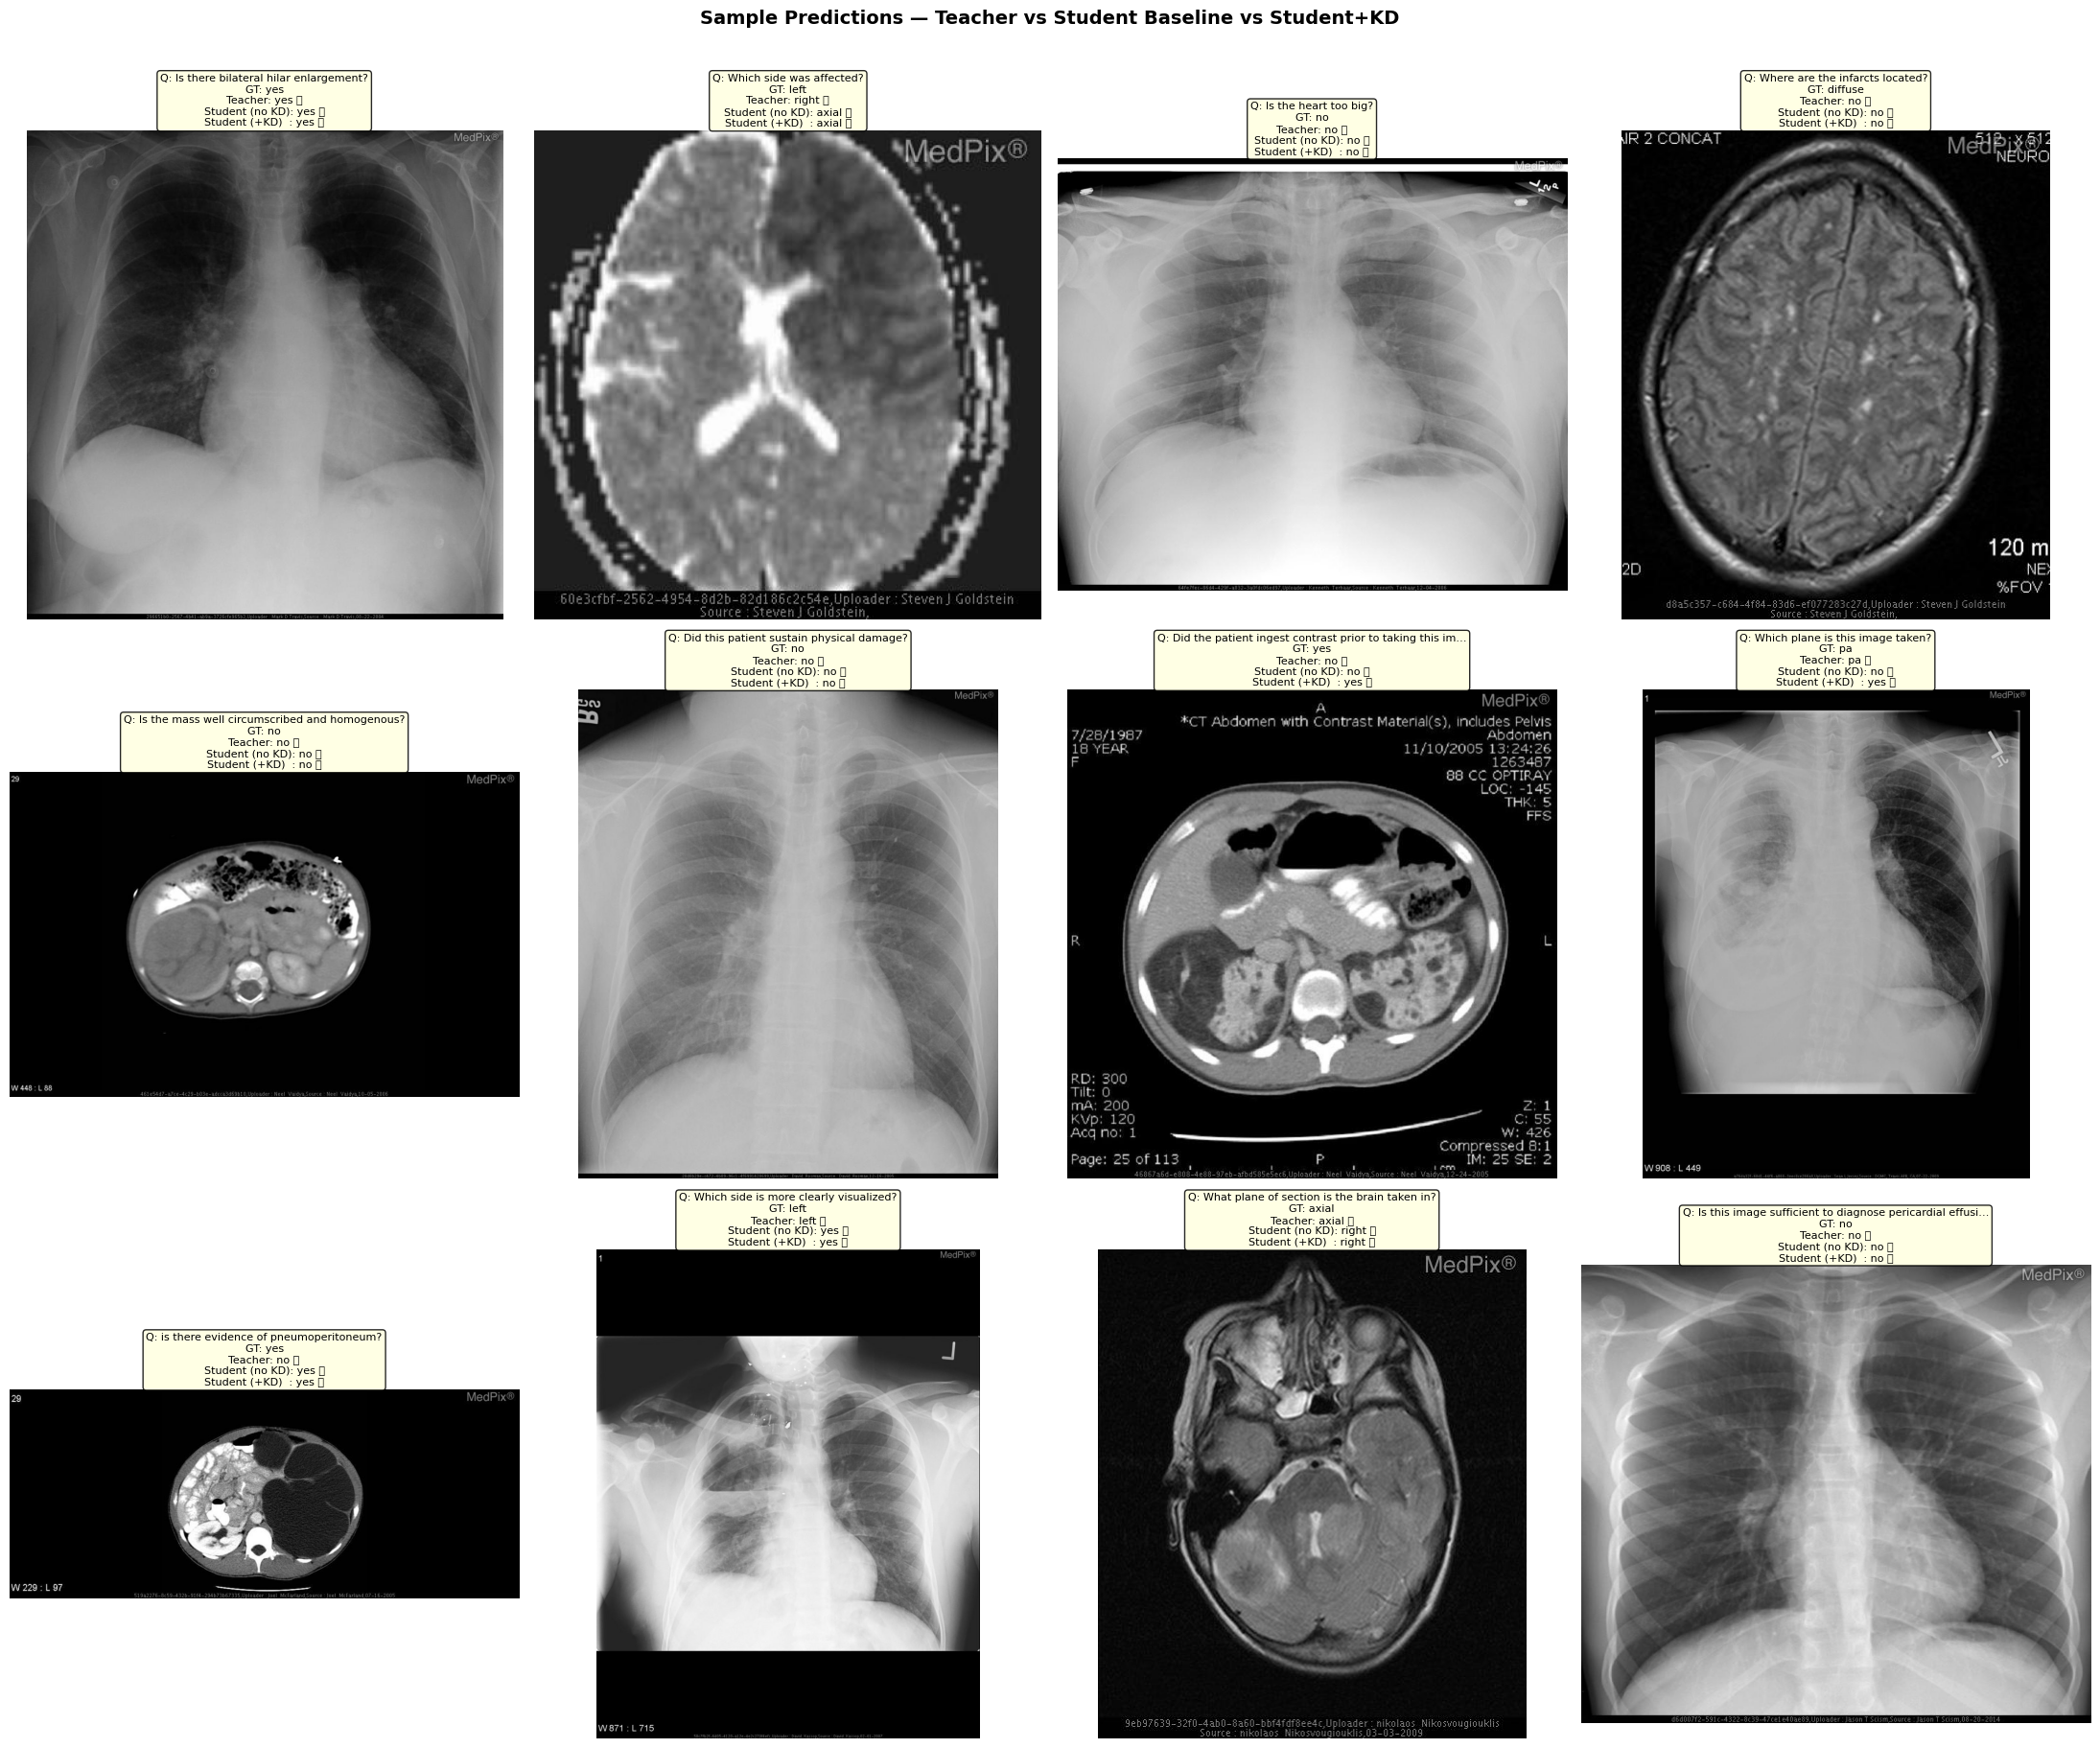

✅ Saved: sample_predictions.png


In [27]:
import matplotlib.pyplot as plt   # ← required for sample visualisation

@torch.no_grad()
def get_predictions_sample(teacher, student_bl, student_kd, dataset, n=12, device=DEVICE):
    teacher.eval(); student_bl.eval(); student_kd.eval()
    indices = random.sample(range(len(dataset)), n)
    results = []
    for idx in indices:
        item       = dataset[idx]
        clip_img   = item['clip_img'].unsqueeze(0).to(device)
        mobile_img = item['mobile_img'].unsqueeze(0).to(device)
        label      = item['label'].item()
        question   = item['question']

        # Teacher uses image + text tokens
        tokens    = tokenize_questions([question], device)
        t_logits, _  = teacher(clip_img, tokens)
        sb_logits, _ = student_bl(mobile_img)
        kd_logits, _ = student_kd(mobile_img)

        results.append({
            'image_path'   : dataset.df.iloc[idx]['image_path'],
            'question'     : question,
            'true_answer'  : item['answer'],
            'gt_label'     : label,
            'teacher_pred' : le.classes_[t_logits.argmax(1).item()],
            'baseline_pred': le.classes_[sb_logits.argmax(1).item()],
            'kd_pred'      : le.classes_[kd_logits.argmax(1).item()],
        })
    return results


samples = get_predictions_sample(teacher, student_baseline, student_kd, test_ds, n=12)

n_cols = 4
n_rows = (len(samples) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 6))
axes = axes.flatten()

for i, s in enumerate(samples):
    ax = axes[i]
    try:
        img = Image.open(s['image_path']).convert('RGB')
        ax.imshow(img)
    except Exception:
        ax.set_facecolor('#111')

    gt   = s['true_answer']
    t    = s['teacher_pred']
    b    = s['baseline_pred']
    k    = s['kd_pred']
    t_ok = '✅' if t == gt else '❌'
    b_ok = '✅' if b == gt else '❌'
    k_ok = '✅' if k == gt else '❌'

    q_short = s['question'][:55] + ('…' if len(s['question']) > 55 else '')
    title = (
        f"Q: {q_short}\n"
        f"GT: {gt}\n"
        f"Teacher: {t} {t_ok}\n"
        f"Student (no KD): {b} {b_ok}\n"
        f"Student (+KD)  : {k} {k_ok}"
    )
    ax.set_title(title, fontsize=8, pad=3,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
    ax.axis('off')

for j in range(len(samples), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Predictions — Teacher vs Student Baseline vs Student+KD',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: sample_predictions.png")


## 13. Save All Models & Results

In [38]:
# Save models
torch.save(teacher.state_dict(),         'teacher_clip_vitl.pth')
torch.save(student_baseline.state_dict(),'student_mobilenet_baseline.pth')
torch.save(student_kd.state_dict(),      'student_mobilenet_kd.pth')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Saved:")
for fn in ['teacher_clip_vitl.pth', 'student_mobilenet_baseline.pth',
           'student_mobilenet_kd.pth', 'label_encoder.pkl',
           'performance_metrics.csv', 'efficiency_metrics.csv', 'full_summary.csv']:
    print(f"   {fn}")

print("\n" + "═"*60)
print("        🎉 KNOWLEDGE DISTILLATION COMPLETE")
print("═"*60)
print(f"  Teacher  (CLIP-ViT-L/14)  : {teacher_baseline_acc*100:.2f}%")
print(f"  Student  Baseline (No KD) : {student_baseline_acc*100:.2f}%")
print(f"  Student  + KD             : {student_kd_acc*100:.2f}%  (+{(student_kd_acc-student_baseline_acc)*100:.2f}% gain)")
print(f"  Compression               : {compression}× smaller than teacher")
print(f"  Inference speedup         : {speedup}×")
print("═"*60)

✅ Saved:
   teacher_clip_vitl.pth
   student_mobilenet_baseline.pth
   student_mobilenet_kd.pth
   label_encoder.pkl
   performance_metrics.csv
   efficiency_metrics.csv
   full_summary.csv

════════════════════════════════════════════════════════════
        🎉 KNOWLEDGE DISTILLATION COMPLETE
════════════════════════════════════════════════════════════
  Teacher  (CLIP-ViT-L/14)  : 69.44%
  Student  Baseline (No KD) : 56.02%
  Student  + KD             : 58.33%  (+2.31% gain)
  Compression               : 133.6× smaller than teacher
  Inference speedup         : 42.4×
════════════════════════════════════════════════════════════
